# Convolutional Neural Networks (CNN) for Medical Image Classification

This project was completed as part of a group activity, where each member independently built their own implementation before the group met to compare approaches and refine conclusions together. The code and analysis shown here are my own individual work.


---



## OBJETIVO ##
El objetivo de esta actividad es desarrollar y evaluar distintos modelos de redes neuronales convolucionales (CNN) para la clasificación de imágenes.

Se utiliza un conjunto de radiografías de tórax en posición anteroposterior que mádicos expertos han clasificado asignandolas una etiqueta diagnóstica (NORMAL o PNEUMONIA).

El conjunto se presenta ya dividido en tres subconjuntos, por lo que no es necesario hacer esa división: train (entrenamiento), val (validación) y test (prueba)


## PREAPARACIÓN ##
El siguiente bloque de código son pasos necesarios para permitir que Colab acceda al repositorio de Github donde se encuentran las imágenes.

In [ ]:
# Instala la librería de Kaggle si no está instalado
#!pip install -q kaggle

# Crea la carpeta .kaggle si no existe
!mkdir -p ~/.kaggle

# Sube el archivo kaggle.json desde tu ordenador
from google.colab import files
files.upload()  # Te va a pedir subir el archivo kaggle.json que descargaste

# Mueve el archivo kaggle.json al directorio .kaggle
# (Asegúrate de haber subido 'kaggle.json' previamente)
!cp kaggle.json ~/.kaggle/

# Da permisos de lectura/escritura al archivo
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Descomprime el archivo ZIP
# El nombre del archivo ZIP es el mismo que el del dataset
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

# Verifica la estructura de carpetas (el unzipping crea una carpeta 'chest_xray')
print("Estructura de carpetas creada:")
!ls chest_xray_data/chest_xray

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 95% 2.17G/2.29G [00:40<00:05, 23.1MB/s]
100% 2.29G/2.29G [00:40<00:00, 60.6MB/s]
Estructura de carpetas creada:
chest_xray  __MACOSX  test  train  val


Importaciòn de librerías necesarias

In [ ]:
import os # Para recorrer las carpetas de imágenes
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns # Para graficar la matriz de confusión.
from sklearn.metrics import confusion_matrix, classification_report

# Para crear la CNN
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# from tensorflow.keras.optimizers import Adam
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers



## 1.- Lectura de imágenes y Data augmentation

Los 3 dataset los reescalamos dividiendo sus pixeles entre 255, pero sólo aumentamos los datos de entrenamiento. No aumentamos los de validación ni prueba.  

*flow_from_directory*  recorre el árbol de carpetas que le pasamos como parámetro e interpreta que las subcarpetas que conforman las hojas son las clases, en este caso PNEUMONIA y NORMAL, y se la asigna automáticamente a cada imagen que encuentra dentro de cada subcarpeta de clase.   

El método *ImageDataGenerator* crea imágenes al vuelo y las añade al dataset original. Esto lo hace en tiempo de ejecución. No las guarda en el disco para no aumentar desmesuradamente el tamaño del dataset.
  

**MUY IMPORTANTE**   

Para que la red aprenda es muy importante mezclar los datos (shuffle = True) durante el entrenamiento. Si no se mezclan la red neuronal verá durante la primera mitad de la época solo fotos "Normales" y aprenderá a decir "todo es normal". Luego, de repente, ve solo "Neumonía" y cambia drásticamente sus pesos para decir "todo es neumonía", olvidando lo anterior. Esto hace que el aprendizaje oscile y no converja nunca (el modelo se marea).  

En cambio si se mezclan los datos, la red en cada lote ve variedad ( Normal, Neumonía, Neumonía, Normal, Normal...).
Esto ayuda a que el algoritmo (el descenso del gradiente) encuentre el camino correcto hacia la solución mucho más rápido y estable.

Pero para el dataset de Test (prueba) los datos no se deben mezclar. Si el generador mezcla las imágenes (que es el comportamiento por defecto), las predicciones no coincidirán con las etiquetas reales y la matriz de confusión saldrá mal.
*shuffle=False* crea un generador que lee las imágenes en orden alfabético estricto. Esto garantiza que la imagen 1 sea comparada con la etiqueta 1.

Por último, en el generador de Validación (val) da igual. Keras solo quiere calcular el "promedio" de aciertos. No le importa el orden, solo quiere saber cuántas acertó en total al final de la época. Por lo tanto, aquí no es crítico si está mezclado o no, pero generalmente se deja como viene por defecto (shuffle=True) o se pone False si quieres consistencia estricta, como en nuestro caso

Generador de Entrenamiento:
Found 5216 images belonging to 2 classes.

Generador de Validación:
Found 16 images belonging to 2 classes.

Generador de Prueba:
Found 624 images belonging to 2 classes.

 Imagen guardada: chest_xray_data/chest_xray/chest_xray_data/chest_xray/imagenes_train.png


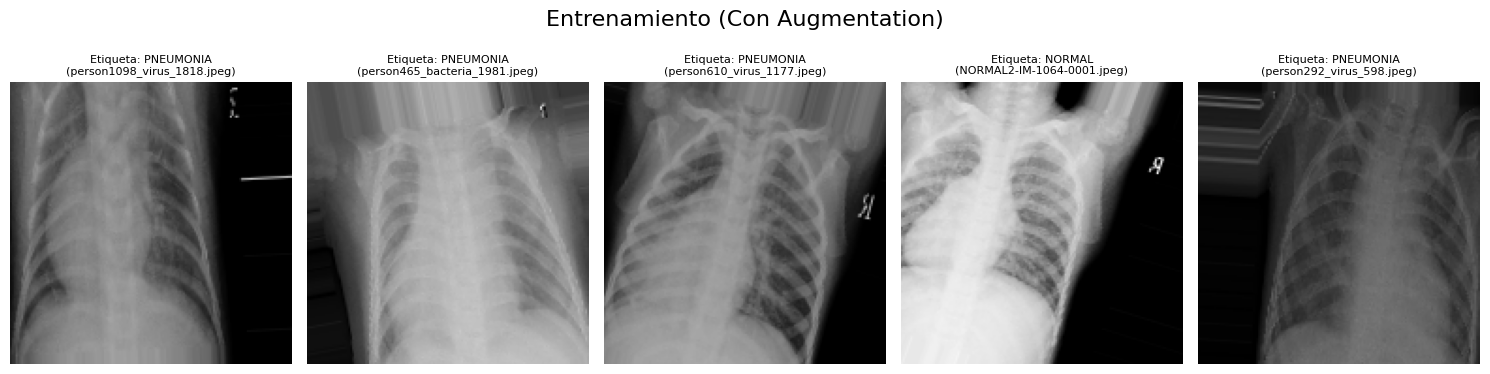


 Imagen guardada: chest_xray_data/chest_xray/chest_xray_data/chest_xray/imagenes_val.png


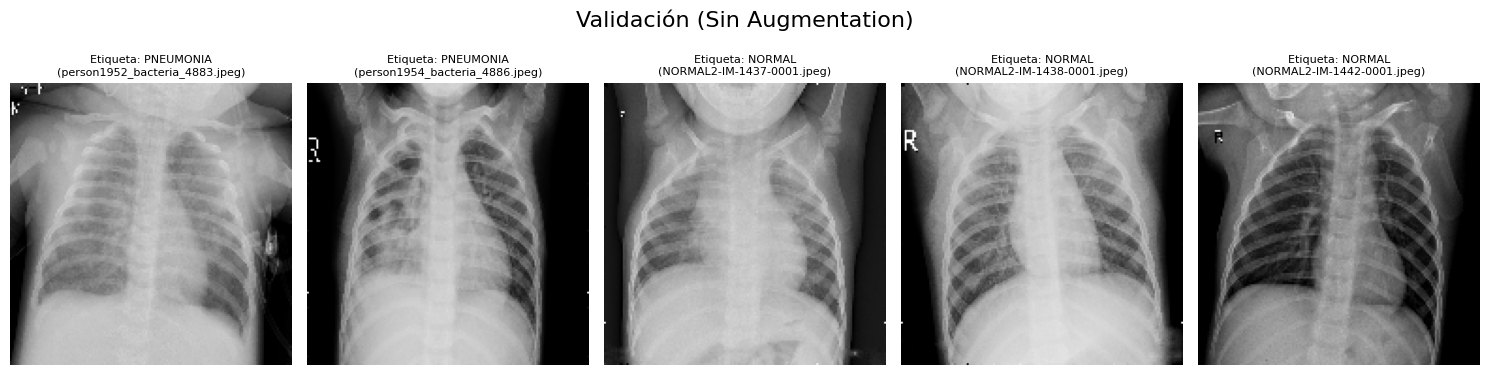


 Imagen guardada: chest_xray_data/chest_xray/chest_xray_data/chest_xray/imagenes_test.png


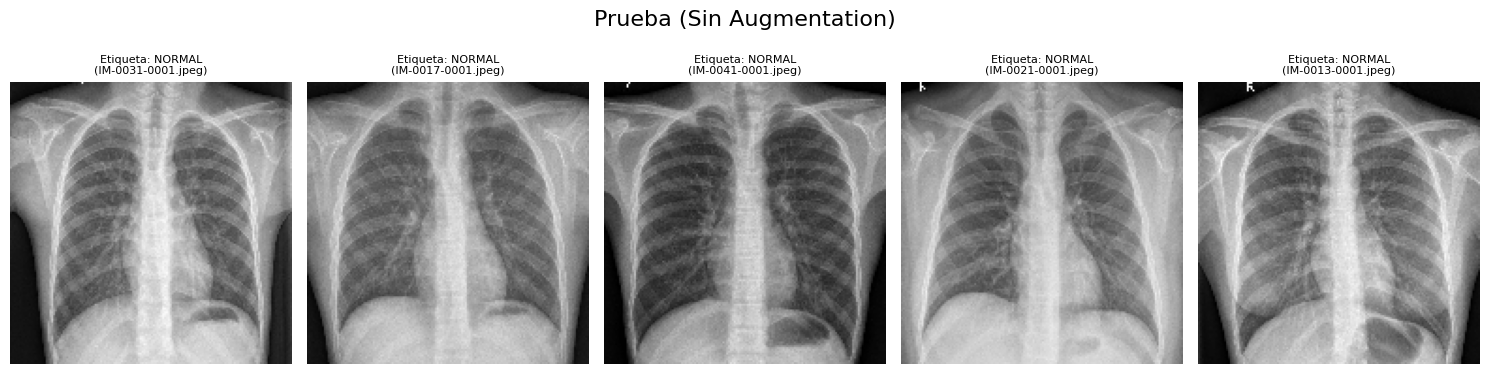


--- Resumen de los Generadores de Datos ---
Mapeo de Clases (0=Normal, 1=Pneumonia): {'NORMAL': 0, 'PNEUMONIA': 1}
Número total de imágenes en Entrenamiento: 5216
Número total de imágenes en Validación: 16
Número total de imágenes en Prueba: 624


In [ ]:
# --- 1. Configuración de Parámetros ---
#ROOT_DIR = 'C:/Users/jmart/4_1_Aprendizaje_Profundo/Actividad1/chest_xray'
ROOT_DIR = 'chest_xray_data/chest_xray'
IMG_SIZE = 150
BATCH_SIZE = 32

# --- 2. Definición de Data Augmentation y Preprocesamiento (Rescaling) ---

# Generador de Entrenamiento (Rescaling + Data Augmentation)
# Rescaling: Rescala cada píxel al rango [0, 1] dividiendo por 255.
# Augmentation: Aplicación de transformaciones aleatorias.
train_datagen = ImageDataGenerator(
    rescale=1./255, # Paso 1: Rescalado (dividir entre 255)
    rotation_range=20,        # Elige un ángulo aleatorio entre -20 y +20 grados.
    width_shift_range=0.2,    # Elige un desplazamiento horizontal aleatorio (hasta el 20% del ancho).
    height_shift_range=0.2,   # Elige un desplazamiento vertical aleatorio (hasta el 20% del alto).
    shear_range=0.2,          # Elige un ángulo de cizallamiento aleatorio.
    zoom_range=0.2,           # Elige un factor de zoom aleatorio (entre 1-0.2 y 1+0.2).
    horizontal_flip=True,     # Decide aleatoriamente (50% de probabilidad) si voltea la imagen.
    brightness_range=[0.5, 1.5], # rango de brillo aleatorio: <1=más oscura, 1= se queda igual, >1= más brillante
    fill_mode='nearest'
)

# Generadores de Validación y Prueba (SÓLO Rescaling, sin Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255) # Paso 1: Rescalado

# --- Generación de Datos por Lotes (Paso 2) ---
target_size = (IMG_SIZE, IMG_SIZE)
class_mode = 'binary' # Para clasificación binaria (dos clases)

# Generador de Entrenamiento
print("Generador de Entrenamiento:")
train_generator = train_datagen.flow_from_directory(
    os.path.join(ROOT_DIR, 'train'),
    target_size=target_size,
    batch_size=BATCH_SIZE,
    class_mode=class_mode,
    shuffle=True #Comportamiento por defecto. Debemos mezclar para que la red aprenda bien
)

# Generador de Validación
print("\nGenerador de Validación:")
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(ROOT_DIR, 'val'),
    target_size=target_size,
    batch_size=BATCH_SIZE,
    class_mode=class_mode,
    shuffle=False
)

# Generador de Prueba
print("\nGenerador de Prueba:")
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(ROOT_DIR, 'test'),
    target_size=target_size,
    batch_size=BATCH_SIZE,
    class_mode=class_mode,
    shuffle=False
)

# --- 3. Visualización de 5 Imágenes al Azar de cada uno de los datasets ---
def plot_random_images(generator, title, file_tag, num_images=5):
    """
    Plots a random sample of images from a data generator,
    garantizando la sincronización del nombre de archivo y la etiqueta
    para lotes aleatorios (shuffle=True).
    """
    # 3.1. Obtener un lote de datos (imágenes y etiquetas)
    images, labels = next(generator)

    # --- 3.2. ACCEDER A LOS NOMBRES DE ARCHIVO REALES DEL LOTE ---

    # Calcular el rango de índices utilizados para este lote dentro de la lista global
    batch_index = generator.batch_index - 1
    if batch_index < 0:
        # Esto ocurre si el generador acaba de terminar una época
        batch_index = len(generator) - 1

    start_index = batch_index * generator.batch_size
    end_index = start_index + images.shape[0]

    # Importante: Usamos index_array para obtener los índices de archivo correctos (tras el shuffle)
    # index_array contiene el orden de los archivos después de la aleatorización
    current_file_indices = generator.index_array[start_index:end_index]

    # Mapear esos índices a la lista maestra de nombres de archivo
    filenames_lote_completos = [
        generator.filenames[i] for i in current_file_indices
    ]

    # --- 3.3 Generar la Visualización propiamente dicha---
    # Obtener el mapeo de clases para mostrar las etiquetas (0->NORMAL, 1->PNEUMONIA)
    class_labels = {v: k for k, v in generator.class_indices.items()}
    plot_count = min(num_images, images.shape[0])

    fig, axes = plt.subplots(1, plot_count, figsize=(3 * plot_count, 4))
    fig.suptitle(title, fontsize=16)

    # Seleccionar índices aleatorios dentro del lote (0 a 31)
    indices_lote_aleatorio = np.random.choice(images.shape[0], size=plot_count, replace=False)

    for i, idx in enumerate(indices_lote_aleatorio):
        img = images[idx]
        label_int = int(labels[idx])
        label_name = class_labels[label_int]

        # El nombre de archivo ahora está perfectamente sincronizado con la imagen y la etiqueta
        file_path_full = filenames_lote_completos[idx]
        file_name_short = os.path.basename(file_path_full)

        ax = axes[i] if plot_count > 1 else axes
        ax.imshow(img)

        # 4. Establecer el título con la etiqueta asignada y el nombre del archivo
        ax.set_title(f'Etiqueta: {label_name}\n({file_name_short})', fontsize=8)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    save_file_name = f'{ROOT_DIR}/imagenes_{file_tag}.png'
    plt.savefig(save_file_name)
    print(f"\n Imagen guardada: {ROOT_DIR}/{save_file_name}")
    plt.show()   # muestra las imágenes en la celda de resultados
    plt.close(fig)

# Plot visualizations
plot_random_images(train_generator, "Entrenamiento (Con Augmentation)", "train", num_images=5)
plot_random_images(val_generator, "Validación (Sin Augmentation)", "val", num_images=5)
plot_random_images(test_generator, "Prueba (Sin Augmentation)", "test", num_images=5)

# Resumen de la información de los generadores
print("\n--- Resumen de los Generadores de Datos ---")
print(f"Mapeo de Clases (0=Normal, 1=Pneumonia): {train_generator.class_indices}")
print(f"Número total de imágenes en Entrenamiento: {train_generator.samples}")
print(f"Número total de imágenes en Validación: {val_generator.samples}")
print(f"Número total de imágenes en Prueba: {test_generator.samples}")
# print(f"Tamaño de imagen (Target Size): {IMG_SIZE}x{IMG_SIZE}")
# print(f"Tamaño de Lote (Batch Size): {BATCH_SIZE}")


## 2.- ENTRENAMIENTO DE REDES ##
Para todos los tipos de redes que vamos a crear tenemos:

- Métrica: exactitud (accuracy)
- Optimizador: Adam
- Tasa de aprendizaje (learning_rsate): 0.001
- Función de pérdida: entropía cruzada (Cross Entrophy)
- Nº epoch: 5
- Tamaño de lote (Batch_size): 32
- Tamaño de imagen (image_size): 150x150x3 canales




### 2.1.- CNN C3D16 (un filtro de 3 × 3 y 16 filtros) - Modelo simple ###
- Activación ReLU
- half-padding
- max-pooling: 2 x 2
- dropout: p de 0.5


En este modelo se utiliza solo 16 filtros porque es la versión más simple de la red. Con este número de filtros el modelo aprende únicamente patrones básicos.

In [ ]:
from tensorflow.keras.optimizers import Adam


# --- 1. Definición de Parámetros ---
IMG_SIZE = 150
LEARNING_RATE = 0.001
EPOCHS = 5

# Vamos a usar train_generator y val_generator que definimos en la celda de código anterior

# --- 2. Creación del Modelo CNN (C3D16) ---
model1 = models.Sequential()

# Añadimos la Capa 1: (Filtro 3x3, 16 filtros) Conv2D equivalente a C3D16
model1.add(layers.Conv2D(
    filters=16,
    kernel_size=(3, 3),
    activation='relu',
    padding='same',              # equivale a half-padding en kernel impar
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
))

    # padding='same' (half-padding) mantiene la dimensión 150x150
    # En la práctica, “half-padding” se implementa como same.
    # Pero técnicamente, en la literatura original:
    #  - half padding = agregar “la mitad” del tamaño del kernel (rounded down)
    #  - same padding = agregar el padding necesario para mantener tamaño

    # Para kernels pares (p. ej. 2×2×2), son distintos.
    # pero para kernels impares (3×3×3) son equivalentes porque:
    #    half padding = floor(3/2) = 1 pixel a cada lado y
    #    same padding = 1 pixel a cada lado



# Añadimos Max-Pooling de 2x2 (Reduce la dimensión a 75x75)
model1.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Añadimos Dropout (p=0.5) sobre la capa previa (output del MaxPooling)
model1.add(layers.Dropout(0.5))

# Añadimos el aplanado de la salida para la capa densa
model1.add(layers.Flatten())

# Añadimos la Capa Densa (Clasificador de Salida)
# Usamos 1 neurona con activación sigmoide para clasificación binaria
model1.add(layers.Dense(1, activation='sigmoid'))


# --- 3. Compilación del Modelo ---
model1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE), # Optimizador Adam con LR definido
    loss='binary_crossentropy', # Pérdida: Entropía cruzada binaria
    metrics=['accuracy']        # Métrica: Exactitud
)

# Imprimir un resumen de la arquitectura
print("--- Resumen de la Arquitectura del Modelo 1 ---")
model1.summary()

# --- 4. Entrenamiento del Modelo ---
print("\n--- Entrenamiento del Modelo (5 Épocas) ---")

# Entrenar utilizando los generadores de datos
history1 = model1.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Resumen de la Arquitectura del Modelo 1 ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 90000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        90,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,449 (353.32 KB)

 Trainable params: 90,449 (353.32 KB)

 Non-trainable params: 0 (0.00 B)


--- Entrenamiento del Modelo (5 Épocas) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 441ms/step - accuracy: 0.7039 - loss: 0.7606 - val_accuracy: 0.6250 - val_loss: 0.7109
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 508ms/step - accuracy: 0.7793 - loss: 0.4741 - val_accuracy: 0.7500 - val_loss: 0.4619
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 486ms/step - accuracy: 0.8209 - loss: 0.4018 - val_accuracy: 0.6250 - val_loss: 0.5427
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 465ms/step - accuracy: 0.8390 - loss: 0.3585 - val_accuracy: 0.6250 - val_loss: 0.9593
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 454ms/step - accuracy: 0.8629 - loss: 0.3187 - val_accuracy: 0.6250 - val_loss: 0.7281


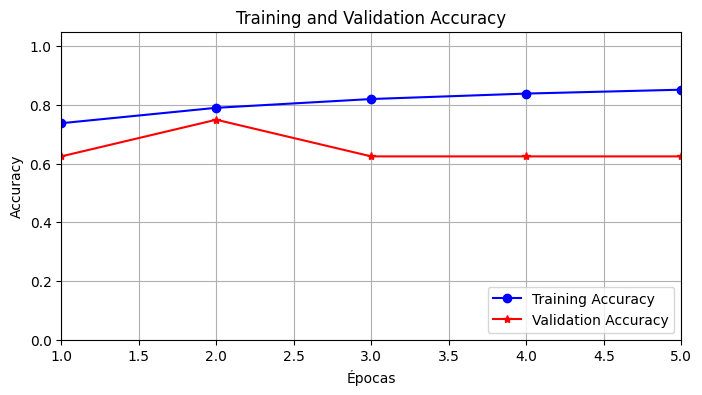

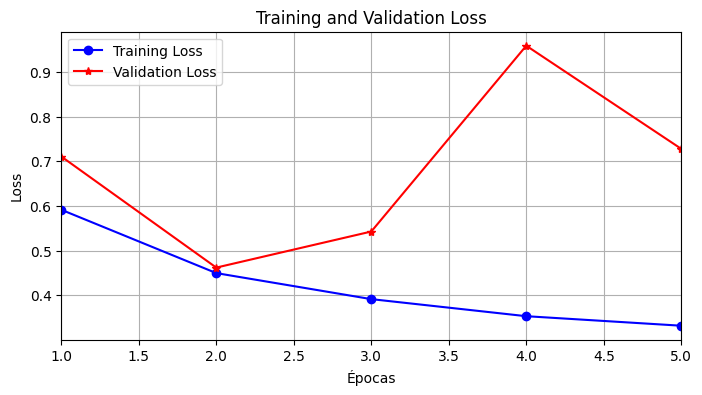

In [ ]:
# Datos de entrenamiento extraídos del historial
acc1 = history1.history['accuracy']
val_acc1 = history1.history['val_accuracy']
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']
epochs1 = range(1, len(acc1) + 1)

# --- GRÁFICO DE ACCURACY CON TEST ---
plt.figure(figsize=(8, 4))

# Curvas de historia
plt.plot(epochs1, acc1, 'bo-', label='Training Accuracy')
plt.plot(epochs1, val_acc1, 'r*-', label='Validation Accuracy')

# LÍNEA DE TEST (Si queremos tener esta línea, la celda hay que moverla
# debajo de la celda donde se comprueba la bondad del modelo con los datos de TEST))
# Dibuja una línea horizontal constante en el valor calculado arriba
# plt.axhline(y=test_acc1, color='green', linestyle='--', linewidth=2, label=f'Test Accuracy ({test_acc1:.2f})')

plt.title('Training and Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

# Ajustes visuales
plt.ylim(0, 1.05)
plt.xlim(1, len(epochs1))
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- GRÁFICO DE LOSS CON TEST ---
plt.figure(figsize=(8, 4))

plt.plot(epochs1, loss1, 'bo-', label='Training Loss')
plt.plot(epochs1, val_loss1, 'r*-', label='Validation Loss')

# LÍNEA DE TEST (Si queremos tener esta línea, la celda hay que moverla
# debajo de la celda donde se comprueba la bondad del modelo con los datos de TEST))
# plt.axhline(y=test_loss1, color='green', linestyle='--', linewidth=2, label=f'Test Loss ({test_loss1:.2f})')

plt.title('Training and Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.margins(0.05)
plt.xlim(1, len(epochs1))

# Nota: Quité el ylim para el loss porque a veces el loss empieza muy alto y se corta el gráfico
plt.legend()
plt.grid(True)
plt.show()

Este modelo muestra Overfitting (Sobreajuste) a partir de la segunda época porque está memorizando el conjunto de entrenamiento pero es incapaz de generalizar lo aprendido a imágenes nuevas. Mientras que la línea de training va mejorando su accuracy y disminuyendo su loss época tras época, la línea de validación tiene un comportamiento errático: En la época 2 su línea de accuracy mejora y luego vuelve a empeorar, pero su línea de loss tiene un ascenso brusco y luego vuelve a bajar.

Esto no se debe a que la red funcione mal, la causa está en que el dataset de validación es muy pequeño (sólo 16 imágenes). La diferencia entre 62% y 68% o 56% es acertar una imagen más o menos:

- $0.625 = \frac{10}{16}$ (acierta 10 imágenes de 16)
- $0.5625 = \frac{9}{16}$ (acierta 9 imágenes de 16)
- $0.6875 = \frac{11}{16}$ (acierta 11 imágenes de 16)  

El modelo está "saltando" de acertar una imagen más o una menos. Esa oscilación no es aprendizaje real, es ruido estadístico porque la muestra es minúscula.

La solución es utilizar el conjunto de Test para validar o mover imágenes de la carpeta de Test a la de validación. PERO NO LO VAMOS A HACER:

- La primera opción es mala porque nos quedaríamos sin dataset de Test (no vamos a probar el modelo con sólo 16 imágenes)
- la segunda no es muy viable porque estamos en Google Colab y es complicado mover imágenes de una carpeta a otra y totalmente inviable hacerlo sobre el repositorio de GitHub de donde lee las imágenes. Además, en las pruebas que hemos hecho los tiempos se alargan enormemente.

Ahora evaluamos el modelo con los datos de Test


In [ ]:
print("\n--- Evaluando el modelo con datos de Test ---")

# Esta línea calcula la loss y el accuracy real sobre los datos de prueba
test_loss1, test_acc1 = model1.evaluate(test_generator)

print(f"Test Accuracy: {test_acc1:.4f}")
print(f"Test Loss: {test_loss1:.4f}")


--- Evaluando el modelo con datos de Test ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.7984 - loss: 0.5312
Test Accuracy: 0.8349
Test Loss: 0.4122


Y generamos la matriz de confusión.  
test_generator (que tiene shuffle=False) crea un generador específico para este gráfico que lee las imágenes en orden alfabético estricto. Esto garantiza que la imagen 1 sea comparada con la etiqueta 1.

Como la red usa sólo una neurona final con sigmoid, la salida es un número decimal entre 0 y 1 (probabilidad) así que lo conviertimos a 0 o 1 puros.

Luego usamos la librería *Seaborn* para dibujar el mapa de calor y con *annot=True* ponemos el número dentro del cuadro.

Por último imprimimos el *classification_report* para ver métricas muy útiles como el Recall (muy importante en medicina para saber cuántos enfermos reales se detectan).


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step


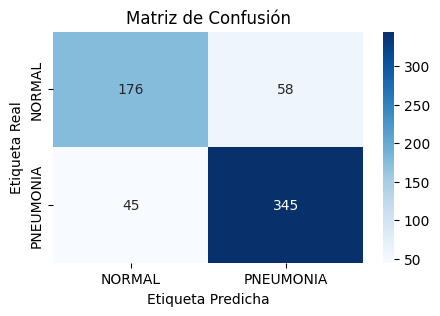


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      NORMAL       0.80      0.75      0.77       234
   PNEUMONIA       0.86      0.88      0.87       390

    accuracy                           0.83       624
   macro avg       0.83      0.82      0.82       624
weighted avg       0.83      0.83      0.83       624



In [ ]:
# Predecimos las probabilidades
Y_pred1 = model1.predict(test_generator)

# Convertimos probabilidades a clases (0 o 1)
# Si es > 0.5 es clase 1 (Pneumonia), si no es 0 (Normal)
y_pred1 = (Y_pred1 > 0.5).astype(int).reshape(-1)

# Obtenemos las etiquetas reales del generador
y_true1 = test_generator.classes

# --- GENERAMOS LA MATRIZ ---
# Calcular la matriz de confusión
cm1 = confusion_matrix(y_true1, y_pred1)

# Obtener los nombres de las etiquetas (Normal, Pneumonia)
class_names = list(test_generator.class_indices.keys())

# --- LA PINTAMOS ---
plt.figure(figsize=(5, 3))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', # fmt='d' formatea el número como entero (sin decimales)
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

# --- REPORTE DETALLADO ---
# Muestra precisión, recall y f1-score por clase
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true1, y_pred1, target_names=class_names))

En medicina detectar la enfermedad es lo principal, así que analizaremos los resultados de la clase PNEUMONIA centrándonos en recall (sensibilidad). La matriz de confusión nos dice que identifica correctamente el 88% de los casos. Aunque parece mucho, realmente se están escapando el 12% de los casos (Falsos negativos), lo cual es un problema porque no se puede enviar a casa a pacientes con neumonía diciéndoles que están sanos.

En cambio, cuando dice que el paciente tiene neumonía acierta el 86% de las veces.

  
    
    

Si analizamos la Clase "NORMAL" vemos que es donde el modelo tiene más problemas.

El Recall nos está diciendo que de todos los pacientes sanos, el modelo solo identifica correctamente al 75%. El otro 25% son personas sanas están siendo clasificadas erróneamente como enfermas (Falsos Positivos). Esto generaría muchas alarmas falsas y pruebas innecesarias en un hospital.

Una Precision del 80% nos está diciendo que si el modelo dice "Está sano", hay un 20% de probabilidad de que se equivoque y en realidad tenga neumonía.

El problema viene porque el dataset está desbalanceado. Si miramos la columna Support tenemos 390 imágenes de Neumonía vs 234 Normales.
El modelo ha visto más ejemplos de neumonía, por lo que ha aprendido a reconocerla mejor (f1-score 0.87) que a los casos normales (f1-score 0.77). El modelo tiene un sesgo hacia predecir "Neumonía".

### Conclusión General ###
El modelo es "conservador" hacia la enfermedad: tiende a diagnosticar neumonía con facilidad (por eso atrapa al 88% de los enfermos), pero a costa de equivocar con muchos sanos (25% de error en normales).  


En general, desde un punto de vista informático, el modelo no está nada mal. Un 83% con una red simple entrenada desde cero es un resultado sólido. Pero desde un punto de vista médico es un desastre porque está enviando muchos enfermos a su casa pasando por sanos Habría que subir el Recall de la clase PNEUMONIA al 95-98% y mejorar la detección de Normales.

### 2.2. MODELO 2 - CNN C3D16 DOS CAPAS CONVOLUCIONALES



En este modelo se aplican dos capas convolucionales y Batch Normalization antes de la función de activación, este normaliza dichas activaciones de cada capa.

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam

# --- 1. Parámetros ---
IMG_SIZE = 150
LEARNING_RATE = 0.001
EPOCHS = 5

model2 = models.Sequential()

print("\n--- Modelo 2 con dos capas convolucionales")

# Bloque Convolucional 1
model2.add(layers.Conv2D(16, (3, 3),
           padding='same',
           input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model2.add(layers.BatchNormalization())               #Antes de la función de activación
model2.add(layers.ReLU())
model2.add(layers.MaxPooling2D(pool_size=(2, 2)))     # 150 → 75
model2.add(layers.Dropout(0.5))

# Bloque Convolucional 2
model2.add(layers.Conv2D(32, (3, 3), padding='same'))
model2.add(layers.BatchNormalization())
model2.add(layers.ReLU())
model2.add(layers.MaxPooling2D(pool_size=(2, 2)))     # 75 → 37


# Aplanado + salida
model2.add(layers.Flatten())
model2.add(layers.Dense(1, activation='sigmoid'))

# --- Compilación ---
model2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

# --- Entrenamiento ---
history2 = model2.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)



--- Modelo 2 con dos capas convolucionales


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43808)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        43,809 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,089 (191.75 KB)

 Trainable params: 48,993 (191.38 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 479ms/step - accuracy: 0.6726 - loss: 2.1583 - val_accuracy: 0.5625 - val_loss: 0.8271
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 442ms/step - accuracy: 0.7476 - loss: 0.7068 - val_accuracy: 0.5000 - val_loss: 2.4150
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 430ms/step - accuracy: 0.8078 - loss: 0.4883 - val_accuracy: 0.5625 - val_loss: 1.3048
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.8157 - loss: 0.5097 - val_accuracy: 0.5000 - val_loss: 2.0325
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 434ms/step - accuracy: 0.7941 - loss: 0.5785 - val_accuracy: 0.5625 - val_loss: 0.8860


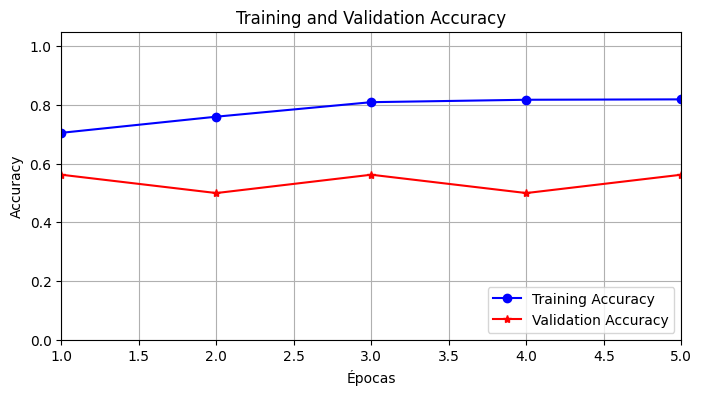

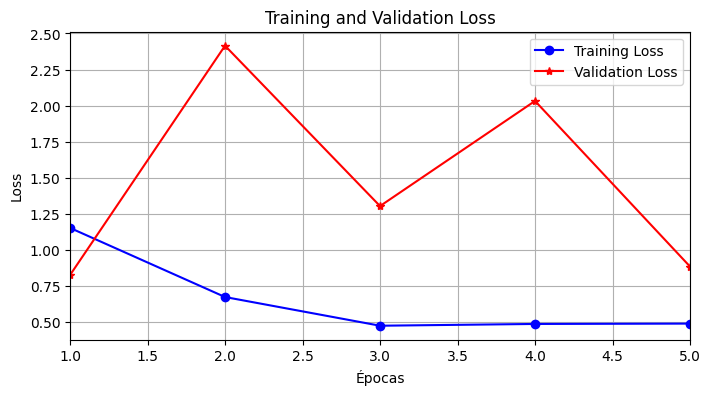

In [ ]:
# Datos de entrenamiento extraídos del historial
acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']
epochs2 = range(1, len(acc2) + 1)

# --- GRÁFICO DE ACCURACY CON TEST ---
plt.figure(figsize=(8, 4))

# Curvas de historia
plt.plot(epochs2, acc2, 'bo-', label='Training Accuracy')
plt.plot(epochs2, val_acc2, 'r*-', label='Validation Accuracy')

# LÍNEA DE TEST (Si queremos tener esta línea, la celda hay que moverla
# debajo de la celda donde se comprueba la bondad del modelo con los datos de TEST))
# Dibuja una línea horizontal constante en el valor calculado arriba
# plt.axhline(y=test_acc1, color='green', linestyle='--', linewidth=2, label=f'Test Accuracy ({test_acc1:.2f})')

plt.title('Training and Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

# Ajustes visuales
plt.ylim(0, 1.05)
plt.xlim(1, len(epochs2))
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- GRÁFICO DE LOSS CON TEST ---
plt.figure(figsize=(8, 4))

plt.plot(epochs2, loss2, 'bo-', label='Training Loss')
plt.plot(epochs2, val_loss2, 'r*-', label='Validation Loss')

# LÍNEA DE TEST (Si queremos tener esta línea, la celda hay que moverla
# debajo de la celda donde se comprueba la bondad del modelo con los datos de TEST))
# plt.axhline(y=test_loss1, color='green', linestyle='--', linewidth=2, label=f'Test Loss ({test_loss1:.2f})')

plt.title('Training and Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.margins(0.05)
plt.xlim(1, len(epochs2))

# Nota: Quité el ylim para el loss porque a veces el loss empieza muy alto y se corta el gráfico
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
so

El gráfico de Accuracy presenta Overfitting (Sobreajuste) por el mismo motivo que la red del punto 2.1: por el tamaño del dataset de validación. Aquí también el modelo está memorizando las imágenes de entrenamiento, por eso la línea azul de train del gráfico de accuracy sube del 70% al 82%, pero es incapaz de generalizar lo aprendido a imágenes nuevas y la línea roja de validación se queda estancado en 50-56% en el mismo gráfico.  

En este caso la diferencia entre 50% y 56% es acertar una imagen más o menos:  
- $0.5 = \frac{8}{16}$ (acierta 8 imágenes de 16)
- $0.5625 = \frac{9}{16}$ (acierta 9 imágenes de 16)



In [ ]:
print("\n--- Evaluando el modelo con datos de Test ---")

# Esta línea calcula la loss y el accuracy real sobre los datos de prueba
test_loss2, test_acc2 = model2.evaluate(test_generator)

print(f"Test Accuracy: {test_acc2:.4f}")
print(f"Test Loss: {test_loss2:.4f}")


--- Evaluando el modelo con datos de Test ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.8275 - loss: 0.5173
Test Accuracy: 0.6106
Test Loss: 1.1123


Y generamos la matriz de confusión igual que la generamos en el punto 2.1


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step


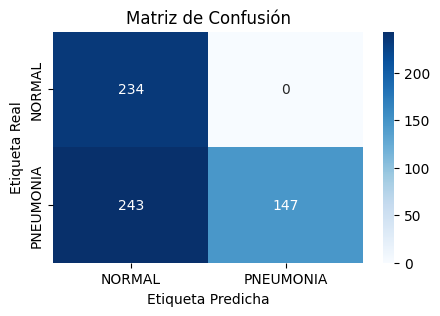


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      NORMAL       0.49      1.00      0.66       234
   PNEUMONIA       1.00      0.38      0.55       390

    accuracy                           0.61       624
   macro avg       0.75      0.69      0.60       624
weighted avg       0.81      0.61      0.59       624



In [ ]:
# Predecimos las probabilidades
Y_pred2 = model2.predict(test_generator)

# Convertimos probabilidades a clases (0 o 1)
# Si es > 0.5 es clase 1 (Pneumonia), si no es 0 (Normal)
y_pred2 = (Y_pred2 > 0.5).astype(int).reshape(-1)

# Obtenemos las etiquetas reales del generador
y_true2 = test_generator.classes

# --- GENERAMOS LA MATRIZ ---
# Calcular la matriz de confusión
cm2 = confusion_matrix(y_true2, y_pred2)

# Obtener los nombres de las etiquetas (Normal, Pneumonia)
class_names = list(test_generator.class_indices.keys())

# --- LA PINTAMOS ---
plt.figure(figsize=(5, 3))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', # fmt='d' formatea el número como entero (sin decimales)
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

# --- REPORTE DETALLADO ---
# Muestra precisión, recall y f1-score por clase
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true2, y_pred2, target_names=class_names))

Esta matriz de confusión muestra un comportamiento radicalmente opuesto a la anterior.

Lo primero que salta a la vista es la fila de NORMAL.

El modelo ha identificado al 100% de las personas sanas: Recall (Normal) = 1.00:. No se equivocó ni una sola vez diciendo que una persona sana tenía neumonía.

Precision (Pneumonia) = 1.00: El 100% de las veces que el modelo se atrevió a decir "Neumonía", tenía razón. No hubo ningún Falso Positivo (decir que alguien está enfermo cuando no lo está).

Aunque esto suen muy bien, realmente el modelo tiene un sesgo hacia la NORMALIDAD que lo convierte en muy peligroso. Es como si el modelo decidiera que "a menos que la radiografía muestre un pulmón completamente destrozado y sea 100% obvio (ese 38% que sí detectó), diré que el paciente está sano para no alarmarlo."

El problema grave está en la fila de PNEUMONIA:  

Recall (Pneumonia) = 0.38 significa que de todos los pacientes que realmente tienen neumonía (390 personas), el modelo solo detectó al 38%. O sea, que que el modelo mandó a casa al 62% de los enfermos (aprox. 242 personas) diciéndoles que estaban sanos. Se han producido Falsos Negativos masivos.

Una precisión de la clase Normal del 49% significa que cuando el modelo dice "Estás Normal", se equivoca la mitad de las veces. Básicamente, ante la duda, el modelo siempre dice "Normal". Predice "Normal" tantas veces que acierta a todos los sanos por pura fuerza bruta, pero también mete en ese saco a la mayoría de los enfermos.  

### Conclusión General ###

Desde unto de vista médico este modelo es inutilizable. Un test médico debe priorizar el Recall de la enfermedad (no dejar escapar enfermos) aunque sacrifique un poco de precisión. Este modelo hace lo contrario: prioriza no alarmar a los sanos, sacrificando a los enfermos.

Técnicamente esto puede estar sucediendo por 2 motivos:
- Entrenamiento insuficiente (Underfitting): El modelo no ha aprendido a distinguir las características sutiles de la neumonía. Solo reconoce los casos más graves y evidentes. Todo lo que es un poco difuso, lo clasifica como la clase 0 (Normal).

- Problema con la función de activación/Umbral: El modelo devuelve una probabilidad entre 0 y 1, y es posible que la mayoría de las predicciones de neumonía estén saliendo muy bajas (ej: 0.45, 0.48, 0.49). Como el corte (threshold) estándar es 0.5, todas esas se convierten en "Normal" (0). Bastaría con bajar el umbral de decisión para detectar más enfermos sin reentrenar.  
p.ej: y_pred2 = (Y_pred2 > 0.2).astype(int).reshape(-1)



### 2.3. MODELO 3 - MODELO MÁS COMPLEJO

Modelo 3 con dos capas de covolución de 32 y 64 filtros, detectando así patrones más complejos. No se usa Batch Normalization por lo que el entranmiento resulta poco estable. Por otro lado, aplicamos un learning rate menor para un aprendizaje más suave y lento.



In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 150
LEARNING_RATE_3 = 0.0007   # aprendizaje más suave.
EPOCHS_3 = 5

# --- 2. Creación del Modelo CNN  ---
model3 = models.Sequential()


# Capa convolucional 1: más filtros que modelos 1 y 2
model3.add(layers.Conv2D(
    filters=32,   # Más aprendixaje sobre un filtro en concreto
    kernel_size=(3, 3),
    activation='relu',
    padding='same',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
))
model3.add(layers.MaxPooling2D(pool_size=(2, 2)))
model3.add(layers.Dropout(0.3))   # Con regularización.

# Capa convolucional 2
model3.add(layers.Conv2D(
    filters=64,   #Aumentamos
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
))
model3.add(layers.MaxPooling2D(pool_size=(2, 2)))
model3.add(layers.Dropout(0.3))

# Aplanado
model3.add(layers.Flatten())

# Más neuronas
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.5))
model3.add(layers.Dense(1, activation='sigmoid'))

# --- 3. Compilación del Modelo 3 ---
model3.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Resumen de la Arquitectura del Modelo 3 ---")
model3.summary()

# --- 4. Entrenamiento del Modelo 3 ---
print("\n--- Entrenamiento del Modelo 3 ---")

history3 = model3.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS_3,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Resumen de la Arquitectura del Modelo 3 ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,234,497 (42.86 MB)

 Trainable params: 11,234,497 (42.86 MB)

 Non-trainable params: 0 (0.00 B)


--- Entrenamiento del Modelo 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 449ms/step - accuracy: 0.7192 - loss: 0.8657 - val_accuracy: 0.5000 - val_loss: 0.6625
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 480ms/step - accuracy: 0.7830 - loss: 0.4345 - val_accuracy: 0.6250 - val_loss: 1.1018
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.8385 - loss: 0.3470 - val_accuracy: 0.6875 - val_loss: 0.7873
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 438ms/step - accuracy: 0.8531 - loss: 0.3136 - val_accuracy: 0.6875 - val_loss: 0.8960
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 448ms/step - accuracy: 0.8694 - loss: 0.2983 - val_accuracy: 0.6250 - val_loss: 1.2728


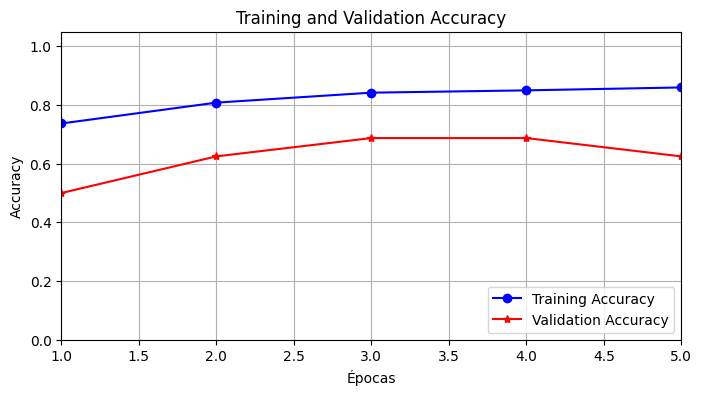

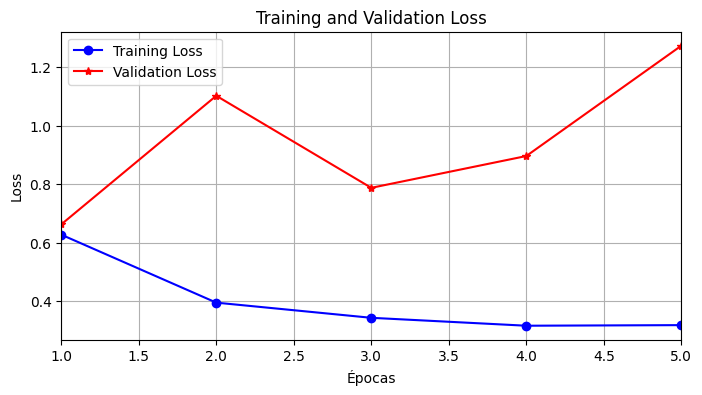

In [ ]:
# Datos de entrenamiento extraídos del historial
acc3 = history3.history['accuracy']
val_acc3 = history3.history['val_accuracy']
loss3 = history3.history['loss']
val_loss3 = history3.history['val_loss']
epochs3 = range(1, len(acc3) + 1)

# --- GRÁFICO DE ACCURACY ---
plt.figure(figsize=(8, 4))

plt.plot(epochs3, acc3, 'bo-', label='Training Accuracy')
plt.plot(epochs3, val_acc3, 'r*-', label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

# Ajustes visuales
plt.ylim(0, 1.05)
plt.xlim(1, len(epochs3))
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- GRÁFICO DE LOSS ---
plt.figure(figsize=(8, 4))

plt.plot(epochs3, loss3, 'bo-', label='Training Loss')
plt.plot(epochs3, val_loss3, 'r*-', label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.margins(0.05)
plt.xlim(1, len(epochs3))
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
print("\n--- Evaluando el modelo con datos de Test ---")

# Esta línea calcula la loss y el accuracy real sobre los datos de prueba
test_loss3, test_acc3 = model3.evaluate(test_generator)

print(f"Test Accuracy: {test_acc3:.4f}")
print(f"Test Loss: {test_loss3:.4f}")


--- Evaluando el modelo con datos de Test ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.5097 - loss: 1.2902
Test Accuracy: 0.7436
Test Loss: 0.7020


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step


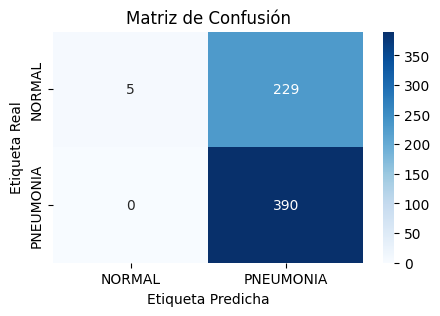


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      NORMAL       1.00      0.02      0.04       234
   PNEUMONIA       0.63      1.00      0.77       390

    accuracy                           0.63       624
   macro avg       0.82      0.51      0.41       624
weighted avg       0.77      0.63      0.50       624



In [ ]:
# Predecimos las probabilidades
Y_pred3 = model3.predict(test_generator)

# Convertimos probabilidades a clases (0 o 1)
# > 0.2 (Normal)
y_pred3 = (Y_pred3 > 0.2).astype(int).reshape(-1)

# Obtenemos las etiquetas reales del generador
y_true3 = test_generator.classes

# --- GENERAMOS LA MATRIZ ---
# Calcular la matriz de confusión
cm2 = confusion_matrix(y_true3, y_pred3)

# Obtener los nombres de las etiquetas (Normal, Pneumonia)
class_names = list(test_generator.class_indices.keys())

# --- LA PINTAMOS ---
plt.figure(figsize=(5, 3))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', # fmt='d' formatea el número como entero (sin decimales)
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

# --- REPORTE DETALLADO ---
# Muestra precisión, recall y f1-score por clase
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true3, y_pred3, target_names=class_names))



El comportamiento de este modelo es justamente lo opuesto al modelo 2, el modelo clasifica todo como Neumonía. Con un threshold muy bajo,  si lo que buscamos es un equilibrio, un umbral tan bajo no sería lo más optimo pero si lo que queremos es que no se nos escape ningún cliente que tenga Neumonía puede ser buena elección.

En la clase NORMAL, el modelo tendría un recall del 2%, identificando solo 5 correctamente como Normal, es decir el 98% de la clase Normal son etiquetados como Neumonía

En cuanto a la clase NEUMONÍA, el modelo detecta el 100% de las neumonías reales sin dejar escapar ni un solo caso. Sin embargo, su precisión es del 63%, lo que significa que el 37% de las veces que se dice Neumonía, realmente es Normal.

### Conclusión General ###

Este modelo provoca falsos positivos ya que diagnostica neumonía incluso donde no existe indicio real. Este modelo solo tendría sentido si la prioridad fuese no perder ningún caso grave y se aceptara clasificar a la mayoría como Normal aún sabiendo que se generan esos falsos positivos.  
Dicho esto,este modelo, haría que cientos de personas sin patología fueran tratadas como infectadas.





## MODELO VGG

Entrenamiento del modelo desde cero utilizando tres bloques convolucionales, esto  permite capturar patrones más complejos y detallados. Después, se incorpora una capa densa que combina esas características y ayuda a mejorar la fase de clasificación. Como la arquitectura es más profunda, se emplea una tasa de aprendizaje baja para que las actualizaciones sean más suaves y estables durante el entrenamiento.



In [ ]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

IMG_SIZE = 150
LR_VGG = 1e-4      # Red mucho más profunda
EPOCHS_VGG = 5

# --- 1. Definición del modelo tipo VGG16 ---
model_vgg = Sequential([
    # Capa de entrada
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Se usa en cada bloque dos conv para aprender más patrones
    # más complejos y profundos sin usar tantos parámetros como una conv grande
    # 1º y 2º Bloque--> Lineas, bordes, sombras



    # Bloque 1 VGG: 2 conv + maxpool
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),      # 150 -> 75

    # Bloque 2 VGG: 2 conv + maxpool
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),      # 75 -> 37

    # Bloque 3 VGG: 2 conv + maxpool
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),      # 37 -> 18


    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# --- 2. Compilación ---
model_vgg.compile(
    optimizer=Adam(learning_rate=LR_VGG),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- Resumen del modelo VGG ---")
model_vgg.summary()

# --- 3. Entrenamiento ---
start_time = time.time()

history_vgg = model_vgg.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS_VGG,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)






--- Resumen del modelo VGG ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,904,353 (41.60 MB)

 Trainable params: 10,904,353 (41.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 471ms/step - accuracy: 0.7448 - loss: 0.5622 - val_accuracy: 0.6250 - val_loss: 0.6684
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 462ms/step - accuracy: 0.8387 - loss: 0.3481 - val_accuracy: 0.7500 - val_loss: 0.4600
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 458ms/step - accuracy: 0.8689 - loss: 0.2911 - val_accuracy: 0.7500 - val_loss: 0.5773
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 463ms/step - accuracy: 0.8737 - loss: 0.2749 - val_accuracy: 0.6875 - val_loss: 0.5902
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 461ms/step - accuracy: 0.8777 - loss: 0.2701 - val_accuracy: 0.6875 - val_loss: 0.6689


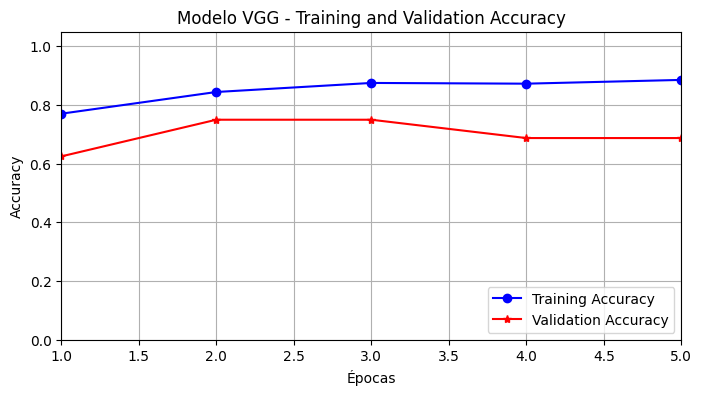

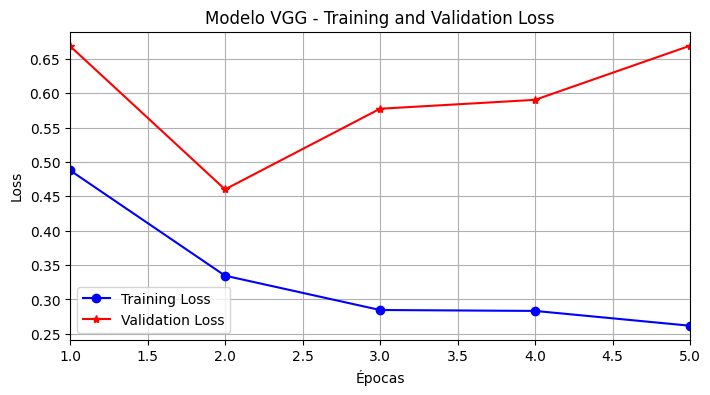

In [ ]:
import matplotlib.pyplot as plt

acc_vgg = history_vgg.history['accuracy']
val_acc_vgg = history_vgg.history['val_accuracy']
loss_vgg = history_vgg.history['loss']
val_loss_vgg = history_vgg.history['val_loss']
epochs_vgg = range(1, len(acc_vgg) + 1)

# --- ACCURACY ---
plt.figure(figsize=(8, 4))
plt.plot(epochs_vgg, acc_vgg, 'bo-', label='Training Accuracy')
plt.plot(epochs_vgg, val_acc_vgg, 'r*-', label='Validation Accuracy')

plt.title('Modelo VGG - Training and Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xlim(1, len(epochs_vgg))
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- LOSS ---
plt.figure(figsize=(8, 4))
plt.plot(epochs_vgg, loss_vgg, 'bo-', label='Training Loss')
plt.plot(epochs_vgg, val_loss_vgg, 'r*-', label='Validation Loss')

plt.title('Modelo VGG - Training and Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.margins(0.05)
plt.xlim(1, len(epochs_vgg))
plt.legend()
plt.grid(True)
plt.show()



--- Evaluando modelo VGG con datos de Test ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.8648 - loss: 0.4046
Test Accuracy: 0.8766
Test Loss: 0.3279
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step


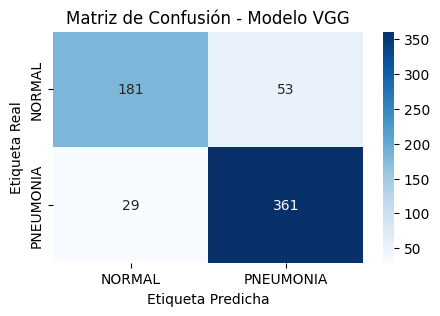


--- Reporte de Clasificación (VGG) ---
              precision    recall  f1-score   support

      NORMAL       0.86      0.77      0.82       234
   PNEUMONIA       0.87      0.93      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.85      0.86       624
weighted avg       0.87      0.87      0.87       624



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

print("\n--- Evaluando modelo VGG con datos de Test ---")
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_generator)
print(f"Test Accuracy: {test_acc_vgg:.4f}")
print(f"Test Loss: {test_loss_vgg:.4f}")

# Predicciones (probabilidades)
Y_pred_vgg = model_vgg.predict(test_generator)

# Threshold 0.40
THRESHOLD = 0.40
y_pred_vgg = (Y_pred_vgg >= THRESHOLD).astype(int).reshape(-1)

# Etiquetas reales
y_true_vgg = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Matriz de confusión
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(5, 3))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo VGG')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("\n--- Reporte de Clasificación (VGG) ---")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))


El modelo VGG entrenado desde cero y ajustado con un threshold de 0.4 ofrece el mejor equilibrio entre sensibilidad y precisión de todos los modelos evaluados. Las métricas muestran que es capaz de detectar correctamente la gran mayoría de los casos de neumonía, en recall 93% sin generar un número excesivo de falsos positivos, manteniendo una precisión del 87%.

En la clase NORMAL también presenta un rendimiento consistente, identificando correctamente el 77% de los casos y logrando una precisión del 86%. Este comportamiento equilibrado entre ambas clases es especialmente relevante en un contexto clínico, donde es fundamental minimizar tanto los casos no detectados de neumonía como los diagnósticos incorrectos.

Con un accuracy global del 87% y un F1-Score medio del 86%, este modelo se posiciona como la opción más robusta y fiable entre las alternativas probadas, ofreciendo un rendimiento estable y adecuado para tareas de apoyo al diagnóstico mediante radiografías de tórax.




## CONCLUSIÓN ##

Después de probar los cuatro modelos y comparar cómo se comportan, se ve claramente que no todos siguen la misma línea ni tienen las mismas prioridades. Cada uno tiende a cometer un tipo distinto de error y eso marca muchísimo el resultado final. El primer modelo, el más sencillo, en general no lo hace mal para lo básico que es. Reconoce la mayoría de los casos de neumonía y acierta también una parte de los casos normales. El problema es que sigue confundiendo demasiadas radiografías sanas con neumonía y eso, en un entorno real, supondría enviar a muchas personas sanas a hacerse más pruebas o a recibir tratamientos innecesarios. Aun así, es un modelo “razonable” para lo simple que es.

El segundo modelo hace justo lo contrario. Intenta no alarmar a nadie, prácticamente todo lo clasifica como normal. Por un lado, acierta con todos los casos sanos, pero por otro deja sin detectar más de la mitad de las neumonías. Esto es algo que no se puede permitir en un escenario médico. Un sistema que dice “todo está bien” cuando no lo está puede causar problemas muy serios. Este modelo, por tanto, aunque a simple vista parezca preciso, está completamente desequilibrado y no sería útil para la realidad.

Con el tercer modelo pasa lo opuesto, se vuelve demasiado sensible y prácticamente todo lo etiqueta como neumonía. Aquí no se escapa ni un solo caso enfermo, lo cual es bueno, pero a cambio convierte a casi todos los pacientes sanos en “falsos enfermos”. El resultado sería que mucha gente sin ningún problema acabaría en consultas y haciéndose pruebas que no necesita. Es un modelo que solo tendría sentido si lo único importante fuese detectar absolutamente todos los casos graves, aunque eso implique sobresaturar el sistema con falsos avisos.

El cuarto modelo, el basado en VGG ajustado con un threshold= 0.4, es el único que consigue un equilibrio real. No es perfecto, pero sí el más coherente de todos. Detecta la gran mayoría de neumonías, que es lo importante, pero al mismo tiempo mantiene una buena capacidad para identificar casos normales sin exagerar ni hacia un lado ni hacia otro. No comete los extremos del modelo 2 ni del modelo 3 y se mantiene estable en casi todas las métricas. Es el modelo que mejor combina sensibilidad y fiabilidad sin caer en los errores tan marcados de los anteriores.

 Esta debe ser la primer celda del NOTEBOOK, donde se inicializan las semillas.

In [ ]:
import os # Para recorrer las carpetas de imágenes
import random
import numpy as np
import tensorflow as tf

# Definimos la semilla
SEED_VALUE = 123

# Limpiamos la memoria de Keras (Vital en Colab para no arrastrar basura entre ejecuciones)
tf.keras.backend.clear_session()

# Configuramos variables de entorno ANTES de importar otras librerías
os.environ['PYTHONHASHSEED'] = str(SEED_VALUE) # Semilla para el entorno Python
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Obliga a usar ops deterministas
os.environ['TF_CUDNN_DETERMINISTIC'] = '1' # Específico para NVIDIA (Colab)

#Fijamos semillas de librerías
random.seed(SEED_VALUE) # Ssemilla en el generador random de Python
np.random.seed(SEED_VALUE) # Semilla en NumPy (muy importante para matrices)
tf.random.set_seed(SEED_VALUE) # semilla en TensorFlow

# Esto le prohíbe a la GPU usar algoritmos aleatorios, pero solo funciona en TensorFlow 2.9+
try:
    tf.config.experimental.enable_op_determinism()
    print("Modo determinista activado exitosamente.")
except AttributeError:
    print("ERROR: La versión de TensorFlow no soporta 'enable_op_determinism'.")

Después, en los tres generadores (train_generator,  val_generator y test_generator), hay que incluir el parámetro ***seed=SEED_VALUE***  para que de siempre el mismo resultado.
Obsérvese que la variable SEED_VALUE la hemos inicializado en la celda anterior.